# HOMEWORK WEEK 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [3]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


#### Dataset

>##### Use only the following columns:
>###### `'engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg'`

In [4]:
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

df_new = df[columns]

df_new

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


#### EDA

>##### Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

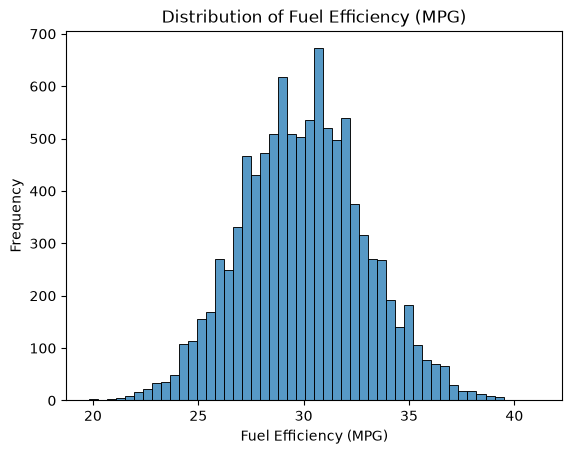

In [5]:
# Determine whether the variable is skewed using histogram

df_fuel = df['fuel_efficiency_mpg'].sort_values().reset_index(drop=True)

sns.histplot(df_fuel, bins=50)
plt.title("Distribution of Fuel Efficiency (MPG)")
plt.ylabel("Frequency")
plt.xlabel("Fuel Efficiency (MPG)")

plt.show()

##### The histogram shows that no long tail at both ends and its shape looks like a dump bell.

## Question 1

#### There's one column with missing values. What is it?

In [6]:
df_new.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

##### Only `horsepower` has missing values.

## Question 2

#### What's the median (50% percentile) for variable 'horsepower'?

In [7]:
df_new['horsepower'].describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

In [8]:
df_new['horsepower'].median()

np.float64(254.0)

#### Prepare and split the dataset

In [9]:
# Split the dataset for train/val/test with 60%/20%/20%
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Set a random seed so the result is reproducible
# Shuffle the dataset to reduce bias from order of the data
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_new.iloc[idx[:n_train]]
df_val = df_new.iloc[idx[n_train:n_train + n_val]]
df_test = df_new.iloc[idx[n_train + n_val:]]


In [10]:
y_train = df_train['fuel_efficiency_mpg'].to_numpy()
y_val = df_val['fuel_efficiency_mpg'].to_numpy()
y_test = df_test['fuel_efficiency_mpg'].to_numpy()


In [11]:
# Reset the index of each dataset
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


In [12]:
# Remove the target variable column to avoid accidentally used for training the model
try:
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    
except:
    print('The dataset does not contain the column.')

## Question 3

>##### 1. Deal with missing values in the column.
>##### 2. Fill it with `0` or with the `mean` of the variable.
>##### 3. Train a linear regression model without regularization for `BOTH OPTIONS`.
>##### 4. Use only `mean` from training data.
>##### 5. Use the validation dataset to evaluate the models and compare the `RMSE` of `BOTH OPTIONS`.

#### Which option gives better `RMSE`?

In [13]:
# Function to compute the weight matrix, w
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack((ones, X))

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [14]:
# Function to compute root mean squared error
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    
    return np.sqrt(mse)

In [15]:
# Selected column for training
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

# Function to obtain feature matrix, X
def prepare_X(df, na=0):
    df_num = df[base]
    df_num = df_num.fillna(na)
    X = df_num.to_numpy()

    return X

>##### Option 1: Fill missing value with `0`

In [16]:
X_train = prepare_X(df_train, na=0)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

score_0 = round(rmse(y_val, y_pred), 3)

score_0

np.float64(2.205)

>##### Option 2: Fill missing value with `mean` value from training data

In [17]:
hp_mean = df_train['horsepower'].mean()

hp_mean

np.float64(254.46338337605272)

In [18]:
X_train = prepare_X(df_train, na=hp_mean)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, na=hp_mean)
y_pred = w0 + X_val.dot(w)

score_mean = round(rmse(y_val, y_pred), 3)

score_mean

np.float64(2.202)

In [19]:
print("Filling missing value")
print("-" * 50)
print(f'With "0", the RMSE is {score_0}.')
print(f'With "mean", the RMSE is {score_mean}.')

Filling missing value
--------------------------------------------------
With "0", the RMSE is 2.205.
With "mean", the RMSE is 2.202.


## Question 4

>##### 1. Train a regularized linear regression.
>##### 2. Fill `NA` with `0`.
>##### 3. Try different values of `r`: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
>##### 4. Use `RMSE` to evaluate the model on the validation dataset.

#### Which `r` gives the best `RMSE`?

In [20]:
# Modify the function with adding regularization.
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack((ones, X))

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [21]:
r = [0, 0.01, 0.1, 1, 5, 10, 100]
score_list = []

for r in r:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 4)

    score_list.append((r, score))
    # print((r, score))


In [22]:
# Compare the rmse value of each 'r'
lowest_rmse = min(score_list, key=lambda x:x[1])[1]

for score in score_list:
    if score[1] == lowest_rmse:
        print("Min -----> %s" % (score,))
    else:
        print(score)

Min -----> (0, np.float64(2.2053))
(0.01, np.float64(2.2058))
(0.1, np.float64(2.2241))
(1, np.float64(2.3492))
(5, np.float64(2.4094))
(10, np.float64(2.4195))
(100, np.float64(2.4292))


## Question 5

>##### 1. Find out how selecting the `seed` influences our score.
>##### 2. Try different `seed` values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
>##### 3. Fill `NA` with `0` and train a model without regularization.
>##### 4. Evaluate the model on the validation dataset and collect the `RMSE` scores for each `seed`.

#### What's the standard deviation of all the scores?

##### Recall

> `n = len(df)`
> 
> `n_val = int(n * 0.2)`
> 
> `n_test = int(n * 0.2)`
> 
> `n_train = n - n_val - n_test`

In [23]:
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []

for s in seed:

    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df_new.iloc[idx[:n_train]]
    df_val = df_new.iloc[idx[n_train:n_train + n_val]]
    df_test = df_new.iloc[idx[n_train + n_val:]]
    
    y_train = df_train['fuel_efficiency_mpg'].to_numpy()
    y_val = df_val['fuel_efficiency_mpg'].to_numpy()
    y_test = df_test['fuel_efficiency_mpg'].to_numpy()

    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    
    rmse_score = rmse(y_val, y_pred)
    scores.append(rmse_score)
    
    print((s, rmse_score))

(0, np.float64(2.239204143046126))
(1, np.float64(2.2021128210838845))
(2, np.float64(2.1634197787530947))
(3, np.float64(2.2043588768539224))
(4, np.float64(2.2018800943311554))
(5, np.float64(2.2457851509085134))
(6, np.float64(2.2697212079524043))
(7, np.float64(2.190794599933443))
(8, np.float64(2.216611201686444))
(9, np.float64(2.2070365928178957))


In [24]:
# Compute the standard deviation for different seeds
std_score = round(np.std(scores), 3)

std_score

np.float64(0.029)

## Question 6

>##### 1. Use `9` as `seed` value.
>##### 2. Combine train and validation datasets.
>##### 3. Fill `NA` with `0` and train a model with `r=0.001`.

#### What's the `RMSE` on the test dataset?

In [25]:
seed = 9
r = 0.001

np.random.seed(seed)
idx = np.arange(n)
np.random.shuffle(idx)

df_full_train = df_new.iloc[idx[:n_train + n_val]]
df_test = df_new.iloc[idx[n_train + n_val:]]

y_full_train = df_full_train['fuel_efficiency_mpg'].to_numpy()
y_test = df_test['fuel_efficiency_mpg'].to_numpy()

X_full_train = prepare_X(df_full_train)
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=r)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = round(rmse(y_test, y_pred), 3)

score

np.float64(2.236)